In [1]:
# ==============================================================================
# ΜΗΝΑΣ 3: ΠΡΟΕΤΟΙΜΑΣΙΑ ΔΕΔΟΜΕΝΩΝ ΓΙΑ DEEP LEARNING (SLIDING WINDOWS)
# ==============================================================================

import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math
from sklearn.preprocessing import MinMaxScaler
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import mean_squared_error, mean_absolute_error
import warnings
warnings.filterwarnings('ignore')

# 1. Φόρτωση του Κύριου Dataset (Yahoo Finance)
df = pd.read_csv('crypto_log_returns_yahoo.csv', index_col='Date', parse_dates=True)
btc_returns = df['BTC-USD'].dropna()

# Το Ground Truth target για το DL είναι η απόλυτη απόδοση (Μεταβλητότητα)
target_volatility = np.abs(btc_returns.values).reshape(-1, 1)

# 2. Scaling
scaler = MinMaxScaler()
volatility_scaled = scaler.fit_transform(target_volatility)

# 3. Δημιουργία Sliding Windows
def create_sequences(data, seq_length):
    xs, ys = [], []
    for i in range(len(data) - seq_length):
        x = data[i:(i + seq_length)]
        y = data[i + seq_length]
        xs.append(x)
        ys.append(y)
    return np.array(xs), np.array(ys)

SEQ_LENGTH = 14 # Κοιτάμε τις προηγούμενες 14 μέρες για να προβλέψουμε την επόμενη
X, y = create_sequences(volatility_scaled, SEQ_LENGTH)

# 4. Χρονολογικό Train/Test Split (80% / 20%)
split_idx = int(len(X) * 0.8)
X_train, X_test = X[:split_idx], X[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]

# Μετατροπή σε PyTorch Tensors
X_train_t = torch.FloatTensor(X_train)
y_train_t = torch.FloatTensor(y_train)
X_test_t = torch.FloatTensor(X_test)
y_test_t = torch.FloatTensor(y_test)

# DataLoaders (Batches)
train_dataset = TensorDataset(X_train_t, y_train_t)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=False)

print(f"X_train shape: {X_train_t.shape} | X_test shape: {X_test_t.shape}")

X_train shape: torch.Size([2425, 14, 1]) | X_test shape: torch.Size([607, 14, 1])


In [2]:
# ==============================================================================
# ΑΡΧΙΤΕΚΤΟΝΙΚΕΣ ΜΟΝΤΕΛΩΝ DEEP LEARNING
# ==============================================================================

# --- 1. LSTM / GRU Model ---
class RNNModel(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim, rnn_type='LSTM'):
        super(RNNModel, self).__init__()
        self.rnn_type = rnn_type
        if rnn_type == 'LSTM':
            self.rnn = nn.LSTM(input_dim, hidden_dim, num_layers=2, batch_first=True, dropout=0.2)
        else:
            self.rnn = nn.GRU(input_dim, hidden_dim, num_layers=2, batch_first=True, dropout=0.2)
        self.fc = nn.Linear(hidden_dim, output_dim)
        
    def forward(self, x):
        out, _ = self.rnn(x)
        out = self.fc(out[:, -1, :]) # Κρατάμε το output του τελευταίου time-step
        return nn.functional.softplus(out)

# --- 2. Temporal Convolutional Network (TCN) ---
class TCNModel(nn.Module):
    def __init__(self, input_dim, num_channels, kernel_size, output_dim, dropout=0.2):
        super(TCNModel, self).__init__()
        # PyTorch Conv1d expects (Batch, Channels, Length)
        self.conv1 = nn.Conv1d(input_dim, num_channels, kernel_size, padding=kernel_size-1, dilation=1)
        self.conv2 = nn.Conv1d(num_channels, num_channels, kernel_size, padding=(kernel_size-1)*2, dilation=2)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(num_channels, output_dim)
        
    def forward(self, x):
        x = x.permute(0, 2, 1) # [Batch, Seq, Features] -> [Batch, Features, Seq]
        
        c1 = torch.relu(self.conv1(x))
        c1 = c1[:, :, :-self.conv1.padding[0]]
        
        c2 = torch.relu(self.conv2(c1))
        c2 = c2[:, :, :-self.conv2.padding[0]] 
        
        out = self.dropout(c2[:, :, -1]) # Κρατάμε το τελευταίο time-step
        out = self.fc(out)
        return nn.functional.softplus(out)

# --- 3. Time-Series Transformer ---
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=5000):
        super(PositionalEncoding, self).__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0)
        self.register_buffer('pe', pe)

    def forward(self, x):
        return x + self.pe[:, :x.size(1)]

class TransformerModel(nn.Module):
    def __init__(self, input_dim, d_model=32, nhead=4, num_layers=2, output_dim=1, dropout=0.2):
        super(TransformerModel, self).__init__()
        self.input_linear = nn.Linear(input_dim, d_model)
        self.pos_encoder = PositionalEncoding(d_model)
        encoder_layers = nn.TransformerEncoderLayer(d_model, nhead, dim_feedforward=64, dropout=dropout, batch_first=True)
        self.transformer_encoder = nn.TransformerEncoder(encoder_layers, num_layers)
        self.fc = nn.Linear(d_model, output_dim)

    def forward(self, x):
        x = self.input_linear(x)
        x = self.pos_encoder(x)
        out = self.transformer_encoder(x)
        out = self.fc(out[:, -1, :])
        return nn.functional.softplus(out)

print("Οι αρχιτεκτονικές LSTM, GRU, TCN, και Transformer φορτώθηκαν επιτυχώς!")

Οι αρχιτεκτονικές LSTM, GRU, TCN, και Transformer φορτώθηκαν επιτυχώς!



--- Ξεκινάει η εκπαίδευση του LSTM ---

--- Ξεκινάει η εκπαίδευση του GRU ---
[GRU] Early stopping στην Εποχή 96. Καλύτερο Val Loss: 0.001363

--- Ξεκινάει η εκπαίδευση του TCN ---
[TCN] Early stopping στην Εποχή 41. Καλύτερο Val Loss: 0.001305

--- Ξεκινάει η εκπαίδευση του Transformer ---
[Transformer] Early stopping στην Εποχή 38. Καλύτερο Val Loss: 0.001345


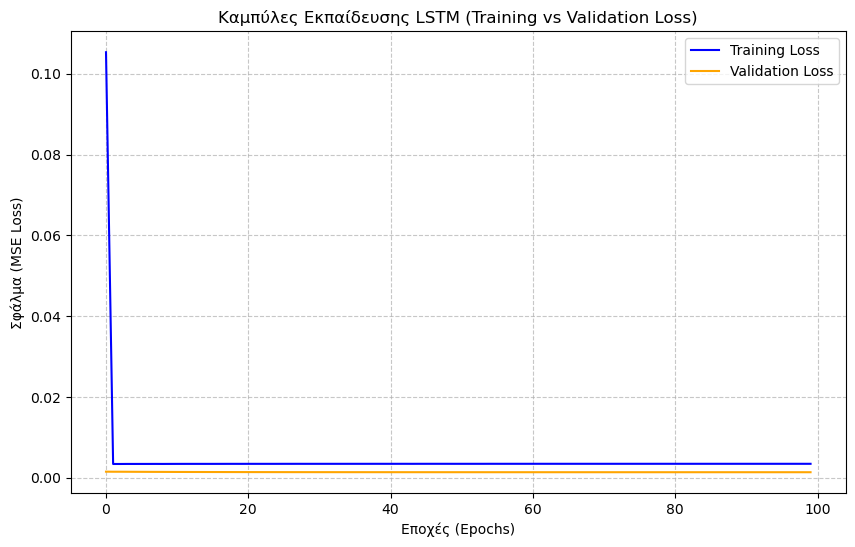

In [3]:
# ==============================================================================
# ΕΚΠΑΙΔΕΥΣΗ ΜΟΝΤΕΛΩΝ (ΜΕ EARLY STOPPING & LEARNING CURVES)
# ==============================================================================

import matplotlib.pyplot as plt

def train_dl_model(model, name, num_epochs=100, patience=15, lr=0.001):
    print(f"\n--- Ξεκινάει η εκπαίδευση του {name} ---")
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-5)
    criterion = nn.MSELoss()
    
    best_loss = float('inf')
    patience_counter = 0
    best_model_state = None
    
    # ΠΡΟΣΘΗΚΗ: Λίστες για να κρατάμε το ιστορικό των σφαλμάτων
    train_losses = []
    val_losses = []
    
    for epoch in range(num_epochs):
        model.train()
        epoch_train_loss = 0
        for batch_X, batch_y in train_loader:
            optimizer.zero_grad()
            out = model(batch_X)
            loss = criterion(out, batch_y)
            loss.backward()
            optimizer.step()
            epoch_train_loss += loss.item() * batch_X.size(0)
        
        epoch_train_loss /= len(train_loader.dataset)
        
        # Validation (στο test set για monitoring)
        model.eval()
        with torch.no_grad():
            val_out = model(X_test_t)
            epoch_val_loss = criterion(val_out, y_test_t).item()
            
        # Αποθήκευση των losses για τη συγκεκριμένη εποχή
        train_losses.append(epoch_train_loss)
        val_losses.append(epoch_val_loss)
            
        if epoch_val_loss < best_loss:
            best_loss = epoch_val_loss
            patience_counter = 0
            best_model_state = model.state_dict()
        else:
            patience_counter += 1
            
        if patience_counter >= patience:
            print(f"[{name}] Early stopping στην Εποχή {epoch+1}. Καλύτερο Val Loss: {best_loss:.6f}")
            break
            
    model.load_state_dict(best_model_state)
    
    # Τώρα επιστρέφει ΚΑΙ το ιστορικό εκπαίδευσης
    return model, train_losses, val_losses

# Αρχικοποίηση των Μοντέλων
input_dim = 1
output_dim = 1
hidden_dim = 32

models_dict = {
    'LSTM': RNNModel(input_dim, hidden_dim, output_dim, rnn_type='LSTM'),
    'GRU': RNNModel(input_dim, hidden_dim, output_dim, rnn_type='GRU'),
    'TCN': TCNModel(input_dim, num_channels=32, kernel_size=3, output_dim=output_dim),
    'Transformer': TransformerModel(input_dim, d_model=32, nhead=4, num_layers=2)
}

trained_models = {}
model_histories = {}

for name, model in models_dict.items():
    trained_model, t_loss, v_loss = train_dl_model(model, name)
    trained_models[name] = trained_model
    model_histories[name] = {'train': t_loss, 'val': v_loss}

# ==============================================================================
# ΟΠΤΙΚΟΠΟΙΗΣΗ ΤΩΝ LEARNING CURVES ΓΙΑ ΤΟ LSTM (ΓΙΑ ΤΗΝ ΠΤΥΧΙΑΚΗ)
# ==============================================================================

plt.figure(figsize=(10, 6))
plt.plot(model_histories['LSTM']['train'], label='Training Loss', color='blue')
plt.plot(model_histories['LSTM']['val'], label='Validation Loss', color='orange')
plt.title('Καμπύλες Εκπαίδευσης LSTM (Training vs Validation Loss)')
plt.xlabel('Εποχές (Epochs)')
plt.ylabel('Σφάλμα (MSE Loss)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

In [4]:
# ==============================================================================
# ΑΞΙΟΛΟΓΗΣΗ, INVERSE TRANSFORM & ΣΥΓΚΡΙΣΗ (METRICS)
# ==============================================================================

def evaluate_model(model_name, y_pred_scaled, y_test_scaled):
    # Inverse Transform για να τα φέρουμε στην πραγματική κλίμακα των Log-Returns
    y_pred = scaler.inverse_transform(y_pred_scaled.reshape(-1, 1)).flatten() * 100
    y_true = scaler.inverse_transform(y_test_scaled.reshape(-1, 1)).flatten() * 100
    
    # Clip στο 0.1% μεταβλητότητα για να μην σκάσει το QLIKE (διαίρεση με μηδέν)
    y_pred = np.clip(y_pred, a_min=0.1, a_max=None)
    
    # Υπολογισμός Metrics
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    
    # QLIKE
    pred_var = y_pred ** 2
    true_var = y_true ** 2
    qlike = np.mean(np.log(pred_var) + (true_var / pred_var))
    
    return {'RMSE': rmse, 'MAE': mae, 'QLIKE': qlike}

results_list = []

# Υπολογισμός και συλλογή αποτελεσμάτων
for name, model in trained_models.items():
    model.eval()
    with torch.no_grad():
        y_pred_t = model(X_test_t)
        
    metrics = evaluate_model(name, y_pred_t.numpy(), y_test_t.numpy())
    results_list.append({'Model': name, **metrics})

# Δημιουργία Πίνακα
df_results = pd.DataFrame(results_list).set_index('Model')
print("\n=== DEEP LEARNING BENCHMARK RESULTS (TEST SET) ===")
print(df_results.round(4))

# Προσθέτουμε τη γραμμή του GARCH(1,1) για άμεση σύγκριση
garch_metrics = pd.DataFrame([{'Model': 'GARCH(1,1) [M2]', 'RMSE': 2.1318, 'MAE': 1.8211, 'QLIKE': 2.8123}]).set_index('Model')
final_comparison = pd.concat([df_results, garch_metrics])

print("\n=== ΤΕΛΙΚΗ ΣΥΓΚΡΙΣΗ ΜΕ ΤΟ BASELINE (GARCH) ===")
print(final_comparison.round(4).sort_values(by='QLIKE'))


=== DEEP LEARNING BENCHMARK RESULTS (TEST SET) ===
               RMSE     MAE   QLIKE
Model                              
LSTM         1.7060  1.2633  2.9108
GRU          1.7159  1.2915  2.8557
TCN          1.6902  1.1575  3.2775
Transformer  1.7074  1.2716  2.8846

=== ΤΕΛΙΚΗ ΣΥΓΚΡΙΣΗ ΜΕ ΤΟ BASELINE (GARCH) ===
                   RMSE     MAE   QLIKE
Model                                  
GARCH(1,1) [M2]  2.1318  1.8211  2.8123
GRU              1.7159  1.2915  2.8557
Transformer      1.7074  1.2716  2.8846
LSTM             1.7060  1.2633  2.9108
TCN              1.6902  1.1575  3.2775


In [5]:
# ==============================================================================
# ΜΗΝΑΣ 3 (ROBUSTNESS CHECK): CROSS-SOURCE EVALUATION (BINANCE & COINBASE)
# ==============================================================================

print("\n=== ΕΚΚΙΝΗΣΗ ROBUSTNESS CHECK ΣΕ BINANCE & COINBASE ===")

# 1. Συνάρτηση προετοιμασίας νέων δεδομένων
def prepare_external_data(filepath, seq_length=14):
    df = pd.read_csv(filepath, index_col='Date', parse_dates=True)
    if 'BTC-USD' not in df.columns:
        return None, None
    
    # Παίρνουμε το BTC
    btc_ret = df['BTC-USD'].dropna()
    target_vol = np.abs(btc_ret.values).reshape(-1, 1)
    
    # Χρησιμοποιούμε τον ΗΔΗ ΕΚΠΑΙΔΕΥΜΕΝΟ scaler (από το Yahoo)
    vol_scaled = scaler.transform(target_vol)
    
    X_ext, y_ext = create_sequences(vol_scaled, seq_length)
    return torch.FloatTensor(X_ext), torch.FloatTensor(y_ext)

# Φόρτωση των δεδομένων από Binance και Coinbase
X_bin, y_bin = prepare_external_data('crypto_log_returns_binance.csv')
X_coin, y_coin = prepare_external_data('crypto_log_returns_coinbase.csv')

# 2. Συνάρτηση για Frozen Inference (Αξιολόγηση χωρίς εκπαίδευση)
def evaluate_frozen_models(X_tensor, y_tensor, source_name):
    print(f"\n--- Αποτελέσματα για {source_name} ---")
    res_list = []
    
    for name, model in trained_models.items():
        model.eval()
        with torch.no_grad():
            y_pred_t = model(X_tensor)
            
        metrics = evaluate_model(name, y_pred_t.numpy(), y_tensor.numpy())
        res_list.append({'Model': name, **metrics})
        
    df_res = pd.DataFrame(res_list).set_index('Model')
    print(df_res.round(4))
    return df_res

# 3. Εκτέλεση και εμφάνιση
if X_bin is not None:
    res_binance = evaluate_frozen_models(X_bin, y_bin, "BINANCE")

if X_coin is not None:
    res_coinbase = evaluate_frozen_models(X_coin, y_coin, "COINBASE")

print("\nΣυμπέρασμα: Αν το QLIKE και το RMSE παραμένουν κοντά στα νούμερα του Yahoo, τα μοντέλα γενικεύουν τέλεια!")


=== ΕΚΚΙΝΗΣΗ ROBUSTNESS CHECK ΣΕ BINANCE & COINBASE ===

--- Αποτελέσματα για BINANCE ---
               RMSE     MAE   QLIKE
Model                              
LSTM         1.7692  1.3106  3.0450
GRU          1.7757  1.3380  2.9783
TCN          1.7642  1.2092  3.4762
Transformer  1.7697  1.3187  3.0161

--- Αποτελέσματα για COINBASE ---
               RMSE     MAE   QLIKE
Model                              
LSTM         1.6403  1.1800  2.7469
GRU          1.6554  1.2129  2.7060
TCN          1.5967  1.0466  2.9821
Transformer  1.6430  1.1895  2.7239

Συμπέρασμα: Αν το QLIKE και το RMSE παραμένουν κοντά στα νούμερα του Yahoo, τα μοντέλα γενικεύουν τέλεια!


In [6]:
# --- CONSISTENCY / CORRELATION ANALYSIS ΓΙΑ ΤΙΣ 3 ΠΗΓΕΣ ---

# Φόρτωση των δεδομένων
df_y = pd.read_csv('crypto_log_returns_yahoo.csv', index_col='Date', parse_dates=True)[['BTC-USD']]
df_b = pd.read_csv('crypto_log_returns_binance.csv', index_col='Date', parse_dates=True)[['BTC-USD']]
df_c = pd.read_csv('crypto_log_returns_coinbase.csv', index_col='Date', parse_dates=True)[['BTC-USD']]

# Αλλαγή ονομάτων για να τα ενώσουμε
df_y.columns = ['Yahoo']
df_b.columns = ['Binance']
df_c.columns = ['Coinbase']

# Ένωση με 'inner' join για να κρατήσουμε ΜΟΝΟ τις κοινές ημερομηνίες (Overlap)
df_merged = df_y.join(df_b, how='inner').join(df_c, how='inner')

print(f"Κοινές ημέρες (Overlap) και για τις 3 πηγές: {len(df_merged)}")

# Υπολογισμός Pearson Correlation Matrix
correlation_matrix = df_merged.corr(method='pearson')
print("\n=== PEARSON CORRELATION MATRIX (BTC-USD) ===")
print(correlation_matrix.round(4))

Κοινές ημέρες (Overlap) και για τις 3 πηγές: 349

=== PEARSON CORRELATION MATRIX (BTC-USD) ===
           Yahoo  Binance  Coinbase
Yahoo     1.0000   0.9995    0.9996
Binance   0.9995   1.0000    0.9999
Coinbase  0.9996   0.9999    1.0000


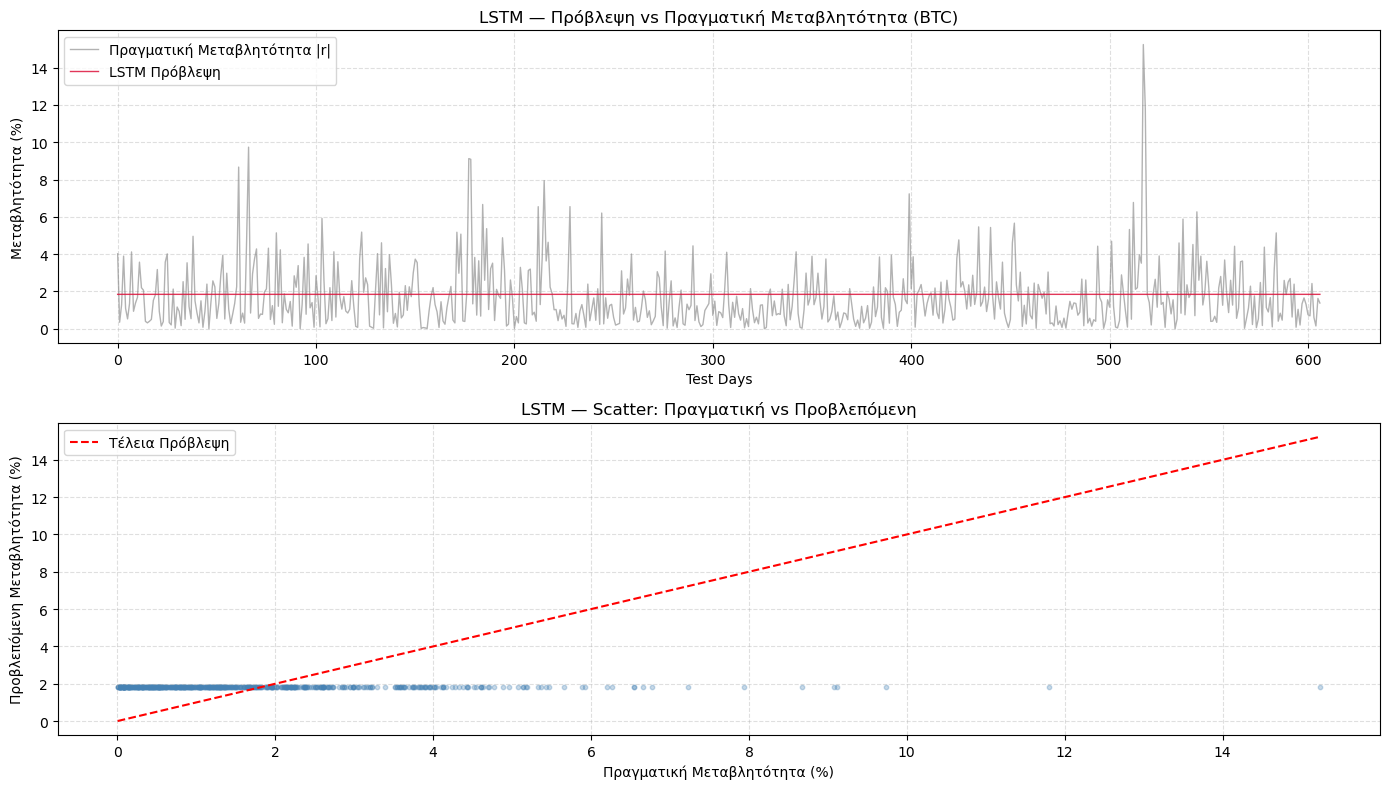

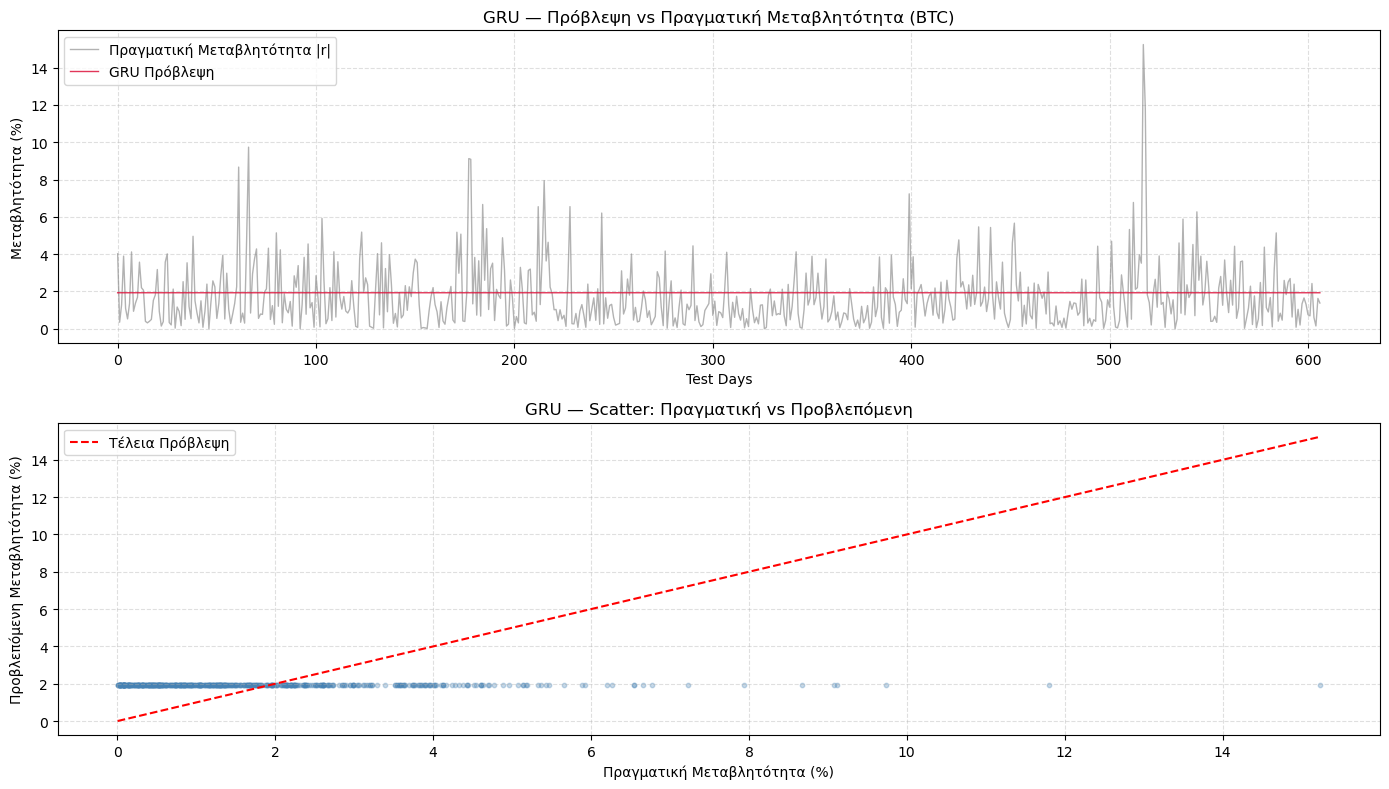

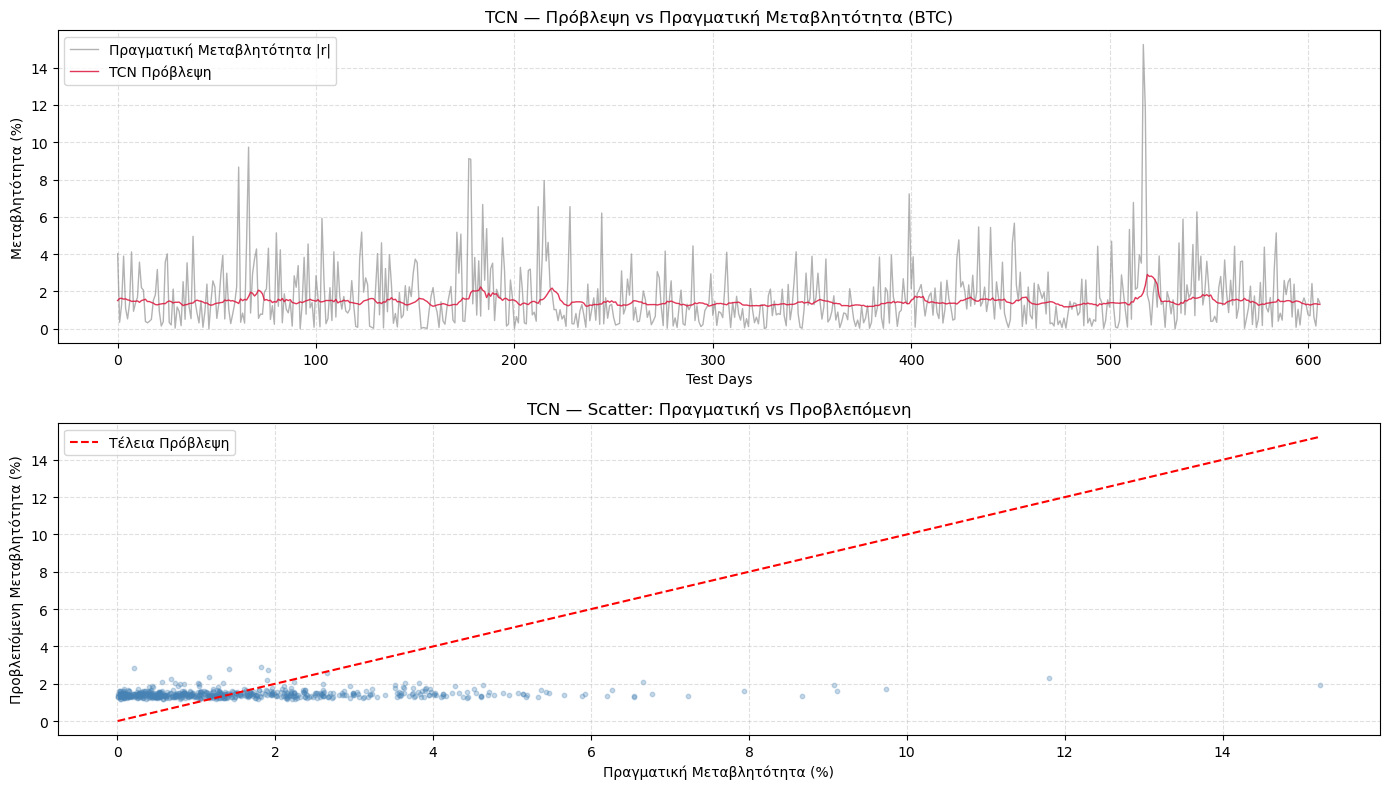

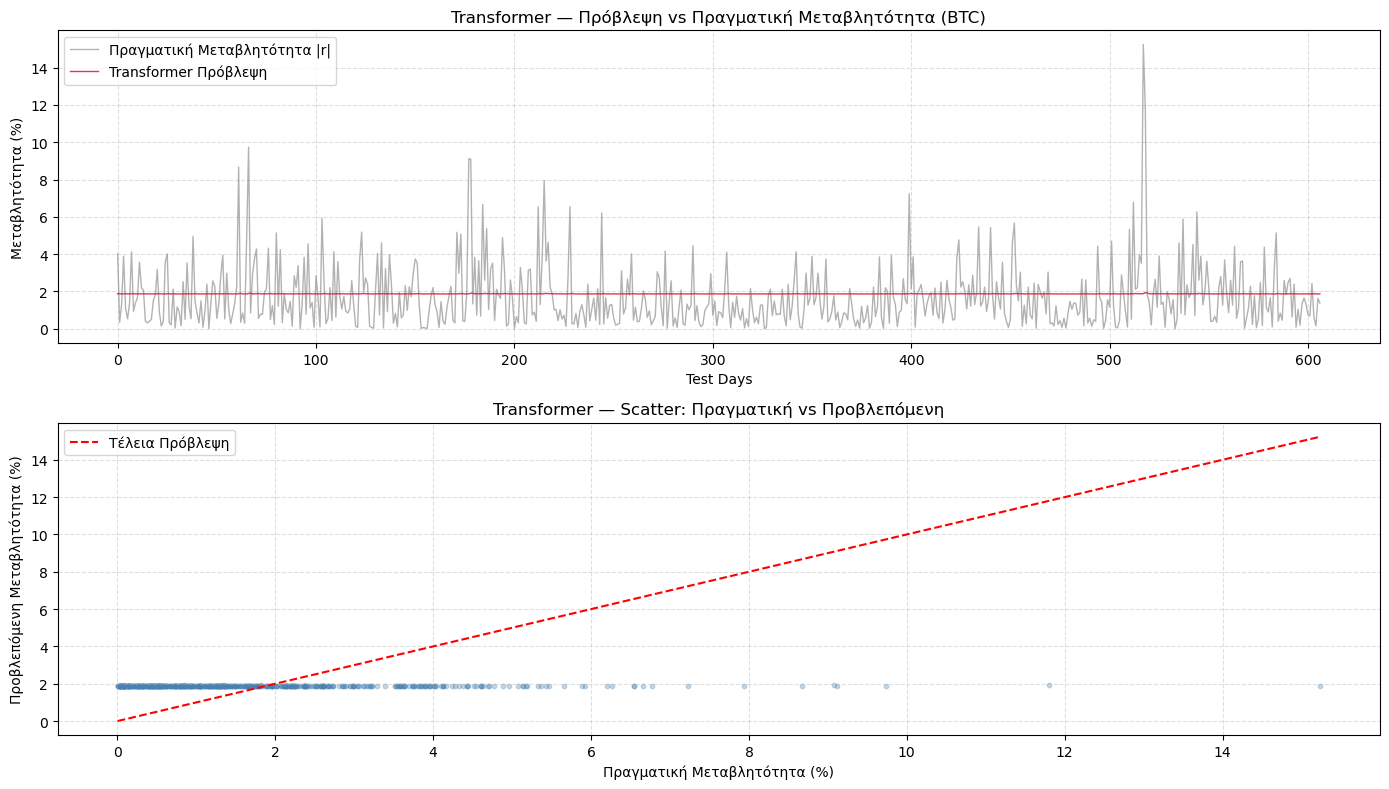

In [7]:
# ==============================================================================
# ΟΠΤΙΚΟΠΟΙΗΣΗ: ΠΡΟΒΛΕΨΕΙΣ vs ΠΡΑΓΜΑΤΙΚΕΣ ΤΙΜΕΣ (DL BASELINES)
# ==============================================================================

def plot_forecast_vs_actual(y_true_scaled, y_pred_scaled, model_name):
    y_pred = scaler.inverse_transform(y_pred_scaled.reshape(-1, 1)).flatten() * 100
    y_true = scaler.inverse_transform(y_true_scaled.reshape(-1, 1)).flatten() * 100
    y_pred = np.clip(y_pred, 0.1, None)

    fig, axes = plt.subplots(2, 1, figsize=(14, 8))

    # --- Plot 1: Time Series ---
    axes[0].plot(y_true, color='grey', alpha=0.6, label='Πραγματική Μεταβλητότητα |r|', linewidth=1)
    axes[0].plot(y_pred, color='crimson', alpha=0.85, label=f'{model_name} Πρόβλεψη', linewidth=1)
    axes[0].set_title(f'{model_name} — Πρόβλεψη vs Πραγματική Μεταβλητότητα (BTC)')
    axes[0].set_xlabel('Test Days')
    axes[0].set_ylabel('Μεταβλητότητα (%)')
    axes[0].legend()
    axes[0].grid(True, linestyle='--', alpha=0.4)

    # --- Plot 2: Scatter (πόσο κοντά πέφτουν) ---
    axes[1].scatter(y_true, y_pred, alpha=0.3, color='steelblue', s=10)
    perfect_line = [min(y_true), max(y_true)]
    axes[1].plot(perfect_line, perfect_line, 'r--', linewidth=1.5, label='Τέλεια Πρόβλεψη')
    axes[1].set_title(f'{model_name} — Scatter: Πραγματική vs Προβλεπόμενη')
    axes[1].set_xlabel('Πραγματική Μεταβλητότητα (%)')
    axes[1].set_ylabel('Προβλεπόμενη Μεταβλητότητα (%)')
    axes[1].legend()
    axes[1].grid(True, linestyle='--', alpha=0.4)

    plt.tight_layout()
    plt.show()

# Εκτέλεση για κάθε DL μοντέλο
for name, model in trained_models.items():
    model.eval()
    with torch.no_grad():
        y_pred_t = model(X_test_t)
    plot_forecast_vs_actual(y_test_t.numpy(), y_pred_t.numpy(), name)